# IAT 461 / 882 — Assignment 2: Modeling Phigma User Behavior

**Name:** Marcus Chan

**SFU ID:** 301455991

**Date:** June 24 2026

---

> Before you start: read the full assignment README on Canvas.  
> Run cells top-to-bottom. Do **not** skip cells — later cells depend on earlier ones.  
> Every cell marked `# YOUR CODE HERE` must be completed.  
> Every cell marked `**✏️ Your interpretation:**` must be filled in with your own words.


## Setup

Run this cell first. It imports all libraries used throughout the notebook.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
ACCENT = '#e8925a'   # course accent colour

print("Libraries loaded.")


Libraries loaded.


---

## Part A — Linear Regression: Did the AI Assistant Change User Behavior?

**Dataset:** `phigma_ab_study.csv`  
**Research question:** Does access to Phigma's AI design assistant increase whiteboard session duration among free-tier users?

This is a **between-subjects experiment**. Users were randomly assigned to treatment (AI access) or control (no AI). We use OLS regression to estimate the effect of the treatment while controlling for other variables.

> **No train/test split in this part.** We are doing statistical inference — explaining the outcome — not predicting future users.


### Load the data

In [4]:
df_ab = pd.read_csv('phigma_ab_study.csv')

print(f"Shape: {df_ab.shape}")
print(f"\nColumn types:\n{df_ab.dtypes}")
print(f"\nFirst 3 rows:")
df_ab.head(3)


Shape: (2000, 12)

Column types:
user_id                                    str
ab_group                                   str
device_type                                str
account_age_days                         int64
prior_whiteboard_sessions                int64
plan_region                                str
num_collaborators                        int64
feature_tour_completed                   int64
templates_used                           int64
ai_suggestions_used                      int64
whiteboard_actions_per_session           int64
avg_whiteboard_session_duration_min    float64
dtype: object

First 3 rows:


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
0,U76582,control,tablet,478,4,EU,3,1,0,0,67,29.70
1,U49158,control,desktop,633,9,APAC,1,0,1,0,72,32.32
2,U82668,control,desktop,159,10,NaN,5,1,1,0,38,17.91


In [5]:
# Summary statistics
df_ab.describe(include='all').round(2)


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
count,2000,2000,2000,2000.00,2000.00,1323,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
unique,1978,2,3,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN
top,U21640,control,desktop,NaN,NaN,EU,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,1011,1211,NaN,NaN,593,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,356.43,4.51,NaN,2.16,0.58,2.79,3.63,84.55,39.53
std,NaN,NaN,NaN,207.82,3.33,NaN,2.37,0.49,2.33,4.87,44.35,20.18
min,NaN,NaN,NaN,7.00,0.00,NaN,0.00,0.00,0.00,0.00,8.00,6.27
25%,NaN,NaN,NaN,178.00,2.00,NaN,0.00,0.00,1.00,0.00,54.00,25.51
50%,NaN,NaN,NaN,352.50,4.00,NaN,1.00,1.00,2.00,0.00,76.00,35.40
75%,NaN,NaN,NaN,533.25,6.00,NaN,3.00,1.00,4.00,7.00,106.00,48.93


In [6]:
# Missing values
df_ab.isnull().sum()


user_id                                  0
ab_group                                 0
device_type                              0
account_age_days                         0
prior_whiteboard_sessions                0
plan_region                            677
num_collaborators                        0
feature_tour_completed                   0
templates_used                           0
ai_suggestions_used                      0
whiteboard_actions_per_session           0
avg_whiteboard_session_duration_min      0
dtype: int64

### A1 — Exploratory Data Analysis

#### A1.1 — Outcome distribution


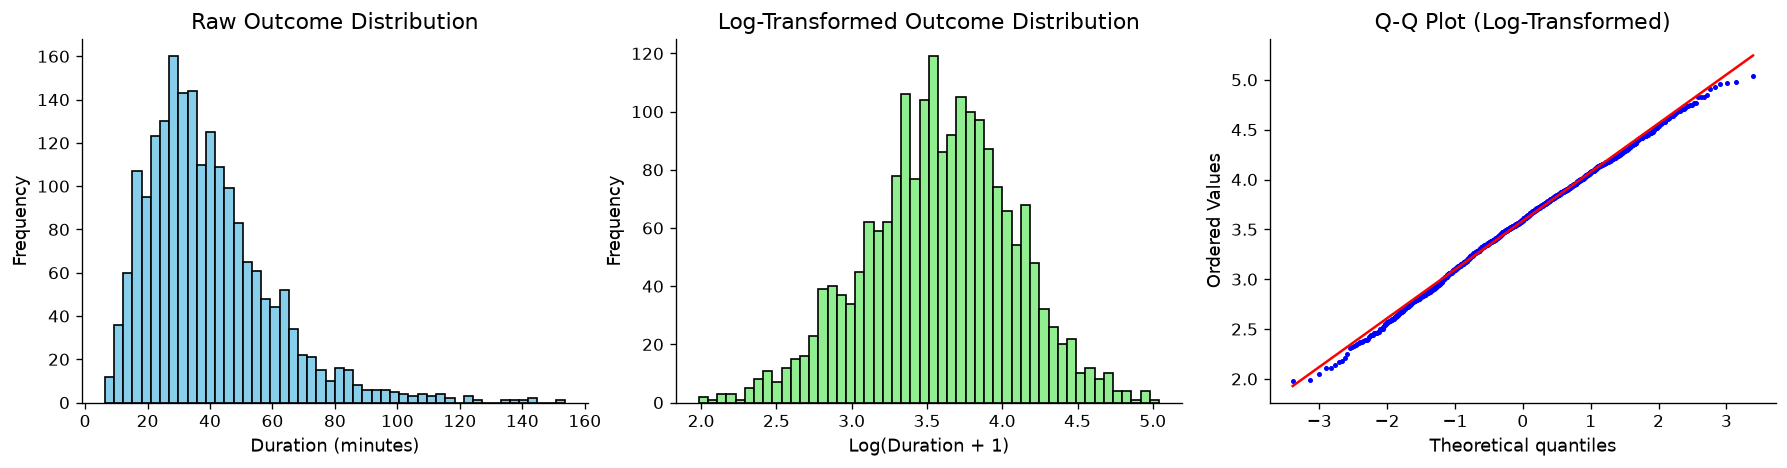

Skewness (raw):             1.3758
Skewness (log-transformed): -0.1627


In [7]:
# BEGIN
# Load target outcome variable
outcome = df_ab['avg_whiteboard_session_duration_min']

# // 1. Normality & Transformation Visualizations
# Initialize three-panel visual layout
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Draw histogram of raw outcome distribution
axes[0].hist(outcome, bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Raw Outcome Distribution')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Frequency')

# Transform outcome variable using natural logarithm
log_outcome = np.log(outcome + 1)  # avoiding log(0)

# Draw histogram of log-transformed outcome distribution
axes[1].hist(log_outcome, bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Log-Transformed Outcome Distribution')
axes[1].set_xlabel('Log(Duration + 1)')
axes[1].set_ylabel('Frequency')

# Draw Q-Q plot comparing log-transformed distribution to a normal distribution
stats.probplot(log_outcome, dist='norm', plot=axes[2])
axes[2].lines[0].set_markersize(2)
axes[2].set_title('Q-Q Plot (Log-Transformed)')

# Render visualizations
plt.tight_layout()
plt.show()

# // 2. Statistical Diagnostics
# Compute and output skewness for both raw and log-transformed distributions
raw_skew = stats.skew(outcome)
log_skew = stats.skew(log_outcome)
print(f"Skewness (raw):             {raw_skew:.4f}")
print(f"Skewness (log-transformed): {log_skew:.4f}")
# END

**✏️ Your interpretation (A1.1):**

**Is the log-transformed outcome more normally distributed?**

Yes, The log-transformed skewness is much more symmetrical.


**How does the Q-Q plot support your conclusion?**

The dots match the line meaning the data is following the expected normal distribution after being transformed

**Will you use the raw or log outcome in your model?**

I will use the log outcome


#### A1.2 — Examine the confounders

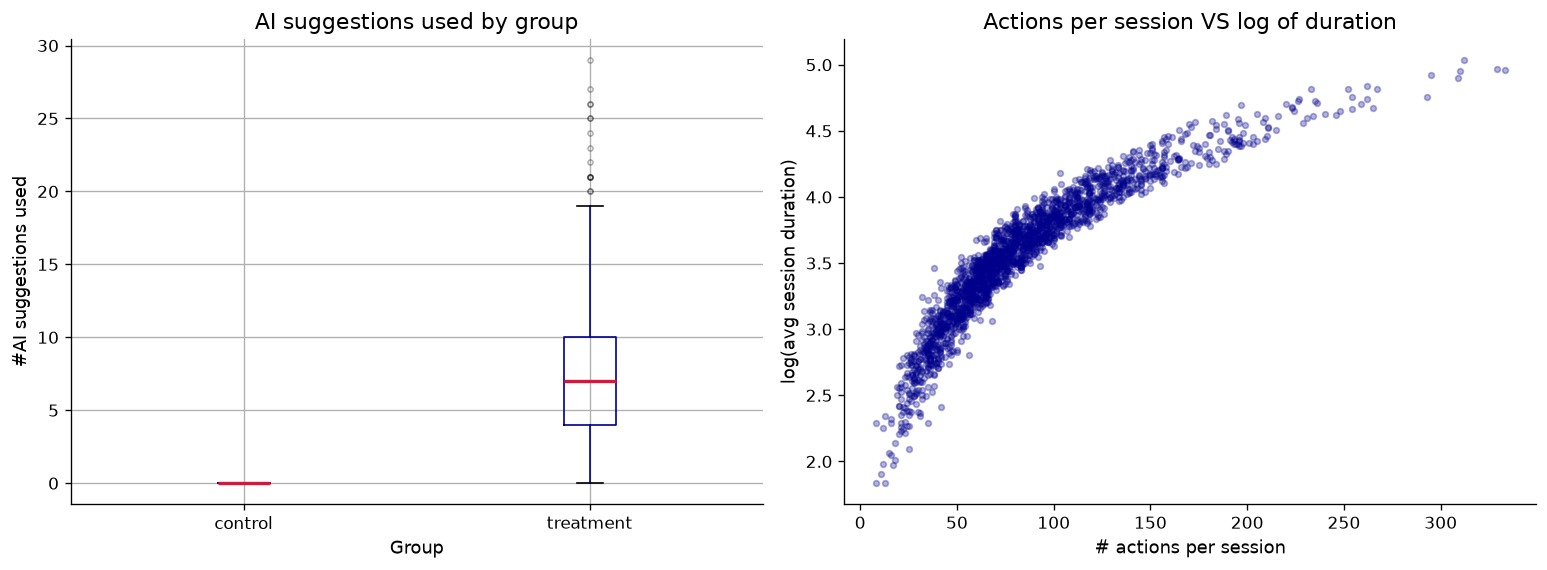

Pearson r (whiteboard_actions_per_session vs log_duration): 0.9136

Descriptive stats for ai_suggestions_used by group:
            count  mean   std  min  25%  50%   75%   max
ab_group                                                
control    1011.0  0.00  0.00  0.0  0.0  0.0   0.0   0.0
treatment   989.0  7.33  4.55  0.0  4.0  7.0  10.0  29.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

#left boxplot of ai suggestions
df_ab.boxplot(column='ai_suggestions_used', by='ab_group', ax=axes[0],
              boxprops=dict(color='darkblue'), medianprops=dict(color='crimson', lw=2),
              whiskerprops=dict(color='darkblue'), capprops=dict(color='black'),
              flierprops=dict(marker='o', color='blue', alpha=0.3, markersize=3)
              )
axes[0].set_xlabel('Group')
axes[0].set_title("AI suggestions used by exp group")
axes[0].set_ylabel('#AI suggestions used')
plt.sca(axes[0])
plt.title("AI suggestions used by group")
plt.suptitle('')

# right side scatter plot of whiteboard actions per session vs log(duration)

log_dur = np.log(df_ab['avg_whiteboard_session_duration_min'])
axes[1].scatter(df_ab['whiteboard_actions_per_session'], log_dur, color='darkblue',
                alpha=0.3, s=12)
axes[1].set_title('Actions per session VS log of duration')
axes[1].set_xlabel('# actions per session')
axes[1].set_ylabel('log(avg session duration)')

plt.tight_layout()
plt.show()


corr_actions = df_ab['whiteboard_actions_per_session'].corr(log_dur)
print(f"Pearson r (whiteboard_actions_per_session vs log_duration): {corr_actions:.4f}")

print("\nDescriptive stats for ai_suggestions_used by group:")
print(df_ab.groupby('ab_group')['ai_suggestions_used'].describe().round(2))


**✏️ Your interpretation (A1.2):**

**What do you notice about `ai_suggestions_used` across the two groups?**

The control is blank because that group was not given access to AI suggestions


**What does the correlation between `whiteboard_actions_per_session` and the outcome suggest?**

Users make more actions as the time passes.


**Why should neither be included in your model?**

Both do not produce any information worth using as the information is redundant. We want information that will help us show if the AI assistant increases time spent on the whiteboard


#### A1.3 — Predictor distributions and relationships with outcome

**** account_age_days ****
**** prior_whiteboard_sessions ****
**** num_collaborators ****


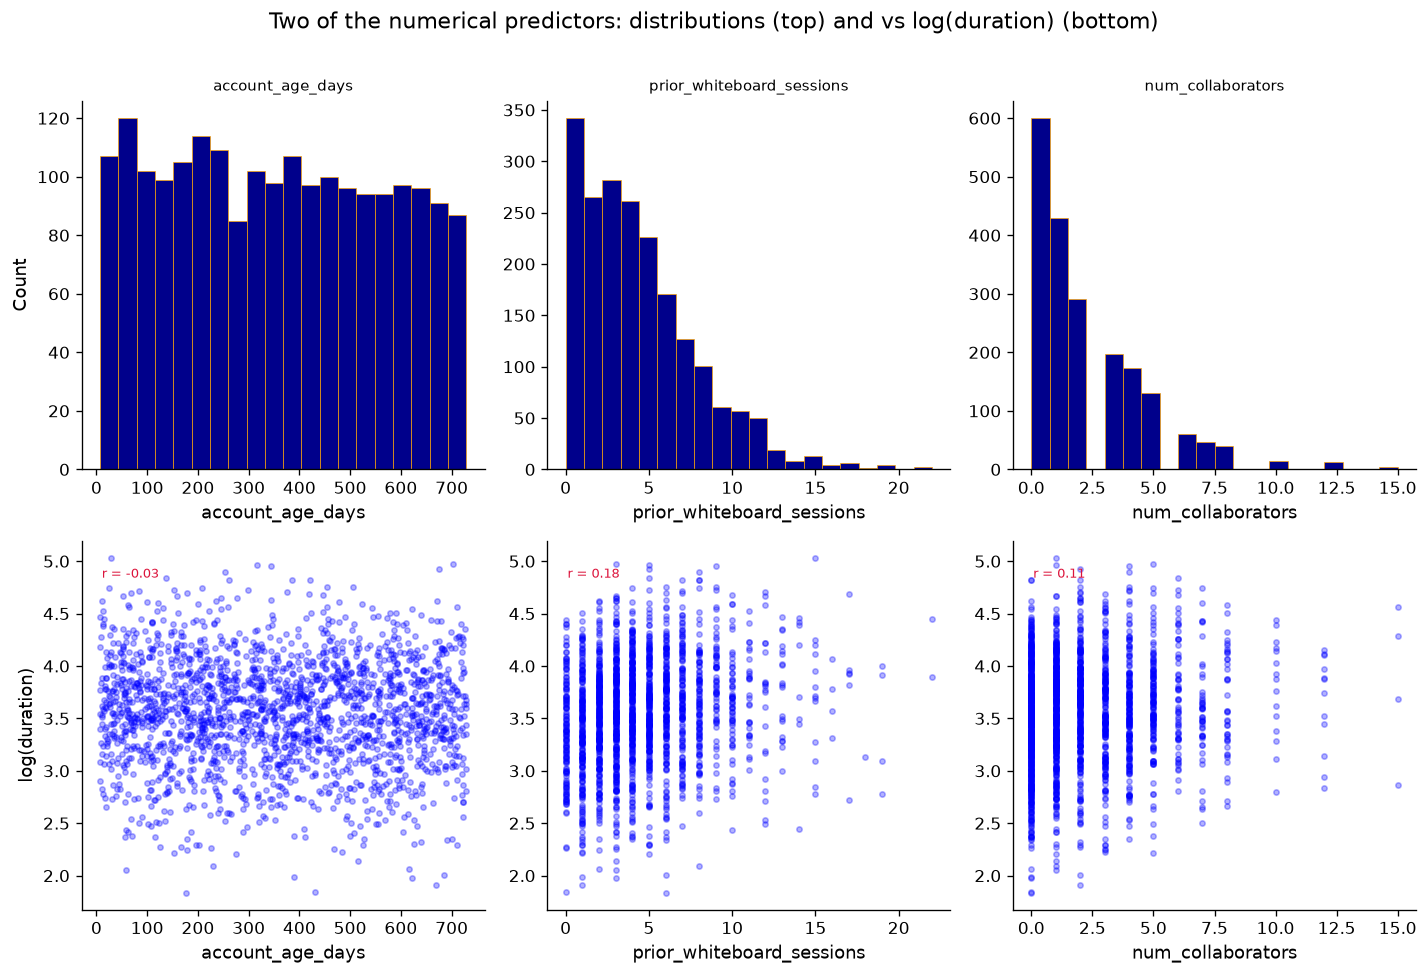

In [9]:
num_predictors = [
    'account_age_days',
    'prior_whiteboard_sessions',
    'num_collaborators'
]

n = len(num_predictors)

fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
fig.suptitle('Two of the numerical predictors: distributions (top) and vs log(duration) (bottom)',
             fontsize=13, y=1.01)

for j, col in enumerate(num_predictors):
    print("****", col, "****")
    #top row: histogram
    axes[0, j].hist(df_ab[col], bins=20, color='darkblue', edgecolor='orange', lw=0.4)
    axes[0, j].set_title(col, fontsize=9)
    axes[0, j].set_xlabel(col)
    axes[0, j].set_ylabel('Count' if j == 0 else '')

    #bottom row: scatterplot
    r = df_ab[col].corr(log_dur)
    axes[1, j].scatter(df_ab[col], log_dur, color='blue', alpha=0.3, s=10)
    axes[1, j].set_xlabel(col)
    axes[1, j].set_ylabel('log(duration)' if j == 0 else '')
    axes[1, j].annotate(f'r = {r:.2f}', xy=(0.05, 0.9),
                         xycoords='axes fraction', fontsize=8, color='crimson')

plt.tight_layout()
plt.show()


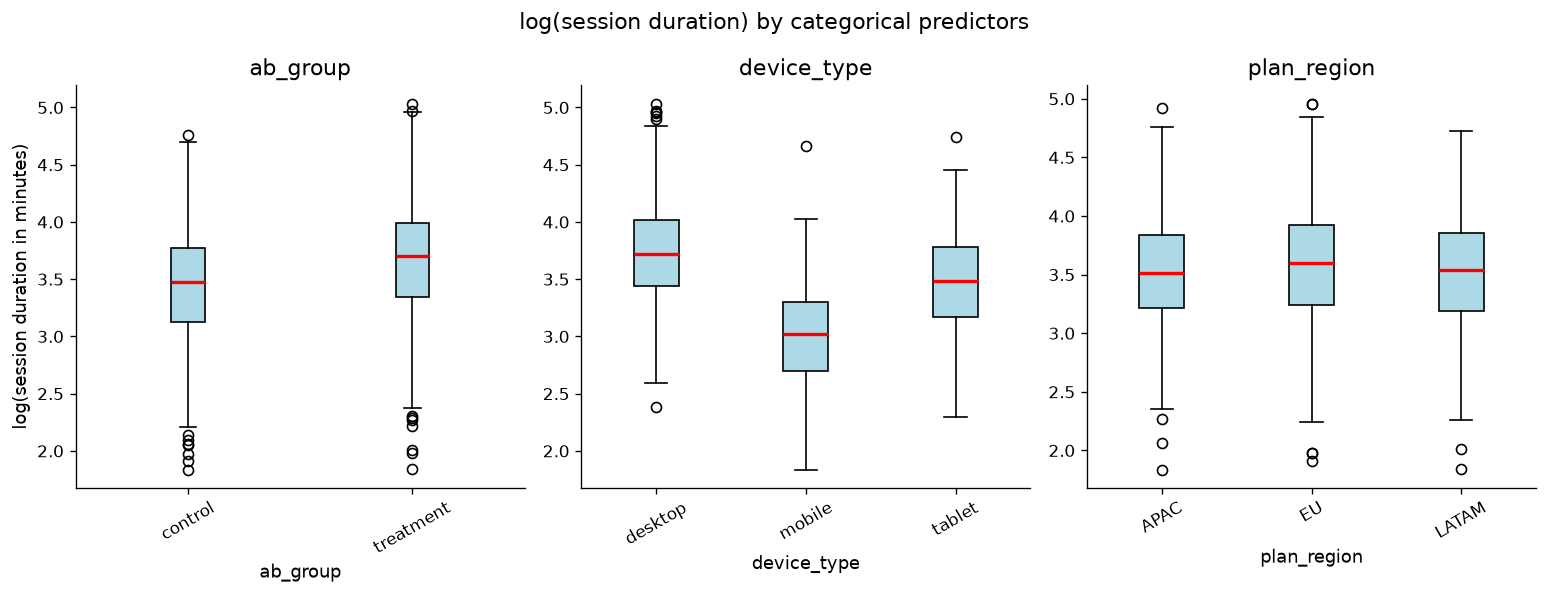

In [10]:
cat_predictors = ['ab_group', 'device_type', 'plan_region']

log_dur = np.log(df_ab['avg_whiteboard_session_duration_min'])

fig, axes = plt.subplots(1, len(cat_predictors), figsize=(13,5))
fig.suptitle('log(session duration) by categorical predictors', fontsize=13)

for j, col in enumerate(cat_predictors):
    levels = sorted(df_ab[col].dropna().unique())
    grouped = [log_dur[df_ab[col] == lvl].values for lvl in levels]
    axes[j].boxplot(grouped, tick_labels=levels, patch_artist=True,
                 boxprops=dict(facecolor="lightblue"), medianprops=dict(color='red', lw=2))

    axes[j].set_title(col)
    axes[j].set_xlabel(col)
    axes[j].set_ylabel('log(session duration in minutes)' if j == 0 else '')
    axes[j].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


**✏️ Your interpretation (A1.3):**

**3–5 sentences summarizing your EDA. Which predictors look most promising?Are any right-skewed and worth log-transforming before use as predictors? Which two features are you excluding and why?**

The EDA reveals that `prior_whiteboard_sessions` and `num_collaborators` are both right-skewed and show the strongest positive correlations with log(duration)(r = 0.18 and r = 0.11), making them the most promising numerical predictors after log-transforming to reduce skew. 


`account_age_days` is roughly uniform with near-zero correlation (r = -0.03),so it contributes little on its own. Among categorical predictors, `device_type` stands out most as the mobile users have a much lower median than desktoop and tablet users. The `ab_group` and `plan_region` boxplots show the medians only differ a bit so they don't look too promising.

Two features are excluded:
-  `whiteboard_actions_per_session` is caused by the treatment itself, so including it would soak up
part of the treatment effect making it look less effective.

-  `ai_suggestions_used` is excluded because control-group users always have a value of zero.






### A2 — Feature Engineering

Prepare your feature matrix for OLS. Exclude the two problematic variables identified in A1.


In [65]:
df_ab['ab_group_enc'] = (df_ab['ab_group'] == 'treatment').astype(int)
device_dummies = pd.get_dummies(df_ab['device_type'], prefix='device', drop_first=True).astype(int)
region_dummies = pd.get_dummies(df_ab['plan_region'], prefix='region', drop_first=True).astype(int)

log_account_age = np.log1p(df_ab['account_age_days'])
log_prior_whiteboard_sessions = np.log1p(df_ab['prior_whiteboard_sessions'])
log_num_collaborators = np.log1p(df_ab['num_collaborators'])

X = pd.concat([
    df_ab['ab_group_enc'].rename('ab_group'),
    log_account_age.rename('log_account_age_days'),
    log_prior_whiteboard_sessions.rename('log_whiteboard_sessions'),
    log_num_collaborators.rename('log_num_collaborators'),
    device_dummies,
    region_dummies
], axis=1)

y = np.log(df_ab['avg_whiteboard_session_duration_min'])

assert X.isnull().sum().sum() == 0
print(f"Feature matrix shape: {X.shape}")
print(f"Missing values in X:  {X.isnull().sum().sum()}")
print(f"\nFeature columns:\n{X.columns.tolist()}")
X.head(3)


Feature matrix shape: (2000, 8)
Missing values in X:  0

Feature columns:
['ab_group', 'log_account_age_days', 'log_whiteboard_sessions', 'log_num_collaborators', 'device_mobile', 'device_tablet', 'region_EU', 'region_LATAM']


,ab_group,log_account_age_days,log_whiteboard_sessions,log_num_collaborators,device_mobile,device_tablet,region_EU,region_LATAM
0,0,6.171701,1.609438,1.386294,0,1,1,0
1,0,6.452049,2.302585,0.693147,0,0,0,0
2,0,5.075174,2.397895,1.791759,0,0,0,0


**✏️ Your interpretation (A2):**

*List your final features. For each one, write one sentence justifying its inclusion and any transformation applied.*

**✏️ Your interpretation (A2):**

- **`ab_group`**: The primary variable of interest; encodes whether the user received the new
  onboarding flow (1) or the original (0).
- **`log_account_age_days`**: Included to control for user experience level; log-transformed
  because account age was applied consistently with the other count variables.
- **`log_whiteboard_sessions`**: Prior usage is a strong predictor of engagement; log-transformed
  because the distribution is right-skewed with a long tail.
- **`log_num_collaborators`**: Users who collaborate more tend to have longer sessions; log-transformed
  because the distribution is heavily right-skewed.
- **`device_mobile`**: Mobile users showed substantially shorter sessions in EDA, so device type
  must be controlled for; desktop is the reference category.
- **`device_tablet`**: Tablet users also showed lower session duration than desktop users, captured
  as a separate dummy from mobile.
- **`region_EU`**: Captures regional differences
- **`region_LATAM`**:  Captures regional differences, 




### A3 — OLS Regression


In [66]:
# YOUR CODE HERE
# Add a constant for the intercept, then fit OLS
X_const = sm.add_constant(X)
model_ols = sm.OLS(y, X_const).fit(cov_type='HC3')
print(model_ols.summary())

                                     OLS Regression Results                                    
Dep. Variable:     avg_whiteboard_session_duration_min   R-squared:                       0.354
Model:                                             OLS   Adj. R-squared:                  0.351
Method:                                  Least Squares   F-statistic:                     122.2
Date:                                 Fri, 03 Jul 2026   Prob (F-statistic):          1.17e-166
Time:                                         17:18:12   Log-Likelihood:                -1034.8
No. Observations:                                 2000   AIC:                             2088.
Df Residuals:                                     1991   BIC:                             2138.
Df Model:                                            8                                         
Covariance Type:                                   HC3                                         
                              coef    st

#### A3.1 — Interpret the model

In [67]:
print(f"R²          = {model_ols.rsquared:.4f}")
print(f"Adj. R²     = {model_ols.rsquared_adj:.4f}")
print()

ab_coef = model_ols.params['ab_group']
ab_pval = model_ols.pvalues['ab_group']

#y = log(duration)

ab_pct_change = (np.exp(ab_coef) - 1)

control_mean = df_ab.loc[df_ab['ab_group'] == 'control', 'avg_whiteboard_session_duration_min'].mean()

ab_mins_effect = control_mean * (np.exp(ab_coef) - 1)

print(f"ab_group coefficient : {ab_coef:.4f}")
print(f"p-value               : {ab_pval:.4f}")
print(f"Back-transformed      : {ab_pct_change:.1%} relative to control mean")
print(f"                      : ~= {ab_mins_effect:.1f} min above control mean ({control_mean:.1f} min)")

# significant predictors with p < 0.05
sig = model_ols.pvalues[model_ols.pvalues < 0.05].sort_values()
print('significant predictors are: ')
for var, pv in sig.items():
    coef = model_ols.params[var]
    print(f"  {var:<35s}  coef = {coef:.4f}  p={pv:.4f}")


R²          = 0.3538
Adj. R²     = 0.3512

ab_group coefficient : 0.2184
p-value               : 0.0000
Back-transformed      : 24.4% relative to control mean
                      : ~= 8.6 min above control mean (35.2 min)
significant predictors are: 
  const                                coef = 3.4148  p=0.0000
  device_mobile                        coef = -0.7244  p=0.0000
  ab_group                             coef = 0.2184  p=0.0000
  device_tablet                        coef = -0.2565  p=0.0000
  log_whiteboard_sessions              coef = 0.1414  p=0.0000
  log_num_collaborators                coef = 0.0878  p=0.0000


**✏️ Results paragraph (A3):**


**Write a results paragraph as if reporting in a research paper. Include:**
- **The treatment effect estimate and its significance**
- **R² and what it tells you about model fit**
- **At least two other notable predictors and their direction**
- **Whether the AI assistant's effect is practically meaningful (not just statistically significant)**


The OLS model estimated a treatment effect of β = 0.2184 on log(session duration) (p < 0.001),
indicating that access to the AI assistant is associated with an approximate 24.4% increase in
average whiteboard session duration, equivalent to roughly 8.6 additional minutes per session
relative to the control-group mean of 35.2 minutes. This effect was statistically significant
well beyond the 0.05 threshold. The model explained R² = 0.354 of the variance in log(session
duration), suggesting that treatment assignment and the included covariates account for a
substantial, though far from complete, share of the variation in engagement, with the remaining
~64.6% attributable to unmeasured factors such as individual user motivation or context of use.
Among the other significant predictors, device type had the largest effect: mobile users had
substantially shorter sessions than desktop users (β = -0.7244, p < 0.001), a magnitude more
than three times larger than the treatment effect, suggesting that device constraints such as
screen size and input method shape engagement more than any single feature. Prior whiteboard
usage was also positively associated with session length (β = 0.1414, p < 0.001), consistent
with more experienced users engaging more deeply per session. Practically, a 24.4% increase
representing nearly 9 extra minutes per session is a meaningful improvement, not merely a
statistically detectable one: given the large sample size (n = 2000), even trivial effects
would reach significance, but an effect of this magnitude reflects a genuine shift in user
behavior rather than a negligible artifact of sample size.







#### A3.2 — Regression diagnostics

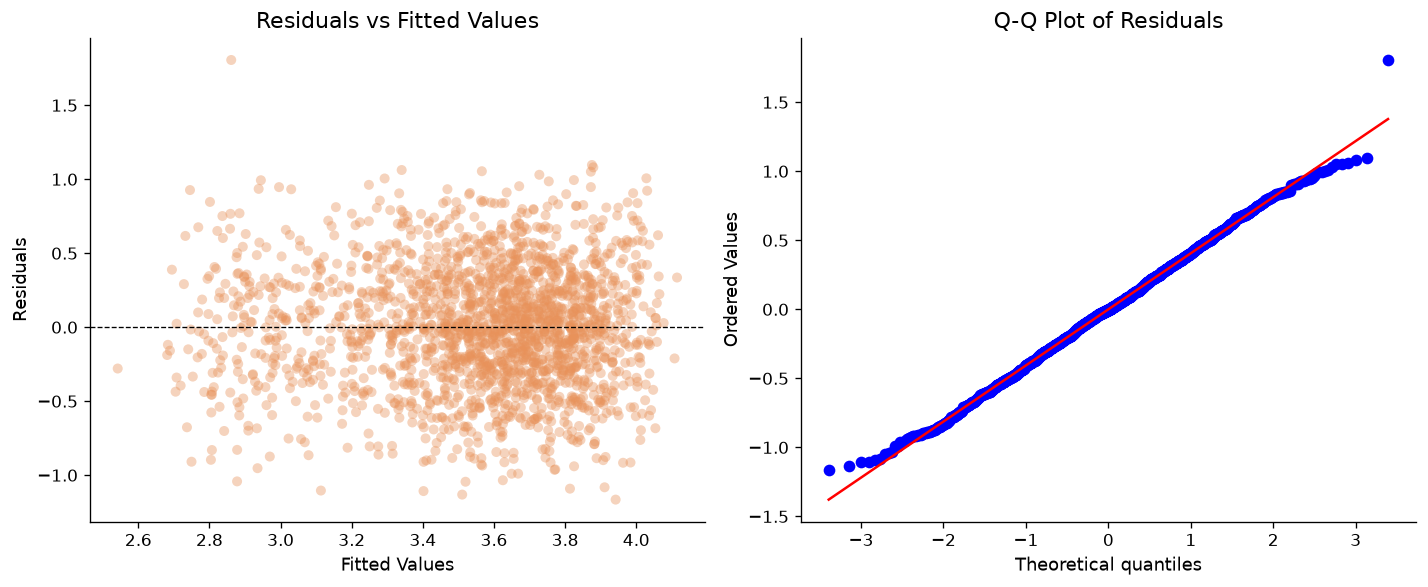

In [68]:
# BEGIN
# Extract predictions and error terms (residuals) from regression model
fitted_vals = model_ols.fittedvalues
residuals = model_ols.resid

# Initialize a side-by-side diagnostic visualization layout
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# // Check for uniform variance (homoscedasticity)
# Draw scatter plot of prediction values vs residuals
axes[0].scatter(fitted_vals, residuals, alpha=0.4, color=ACCENT, edgecolor='none')

# Overlay a horizontal zero-error baseline reference line
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('Residuals vs Fitted Values')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# // Check for normality of errors
# Draw a Q-Q plot of residuals against a normal theoretical distribution
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

# Render diagnostic plots
plt.tight_layout()
plt.show()
# END


**✏️ Your interpretation (A3.2):**

**Do the residuals look randomly scattered around zero?**

Yes, the points are spread evenly above and below the zero line with no funnel shape, so the model's 
variance looks consistent across fitted values.

**Does the Q-Q plot suggest normally distributed errors?**

Mostly. The points follow the diagonal line closely in the middle, but there's a slight deviation at 
the tails, especially one point in the upper right that sits above the line.

**Note any patterns that concern you.**

Just one extreme outlier shows up in both plots. Other than 
that, there's no clear pattern or curve that would suggest a problem with the model.


### A4 — Exploratory Interaction Analysis

The average treatment effect hides heterogeneity — the AI assistant may help some users more than others.


**✏️ State your hypothesis here (before writing any code):**

*Which interaction are you testing? Which two variables? What is your theoretical reason for expecting this interaction? Which group do you predict will benefit more from the AI assistant?*

**Interaction tested:** `ab_group` × `log_prior_whiteboard_sessions`

**Theoretical reason:** The AI assistant provides suggestions and guidance that are most useful
when a user is unfamiliar with the tool. Users with more prior sessions are already comfortable
completing tasks on their own and are less likely to rely on or benefit from AI suggestions.
As a result, the treatment effect should be larger for newer users and smaller for veterans
who have little need for additional assistance.

**Prediction:** Users with fewer prior whiteboard sessions will benefit more from the AI
assistant, showing a larger increase in session duration under treatment. The interaction
coefficient on `ab_group × log_prior_whiteboard_sessions` should be negative: as prior
experience increases, the additional effect of the treatment diminishes.



In [93]:
# Step 1: Create the interaction term
X_int = X.copy()
X_int['ab_x_log_whiteboard'] = X_int['ab_group'] * X_int['log_whiteboard_sessions']

# Step 2: Add constant and refit OLS
model_int = sm.OLS(y, sm.add_constant(X_int)).fit(cov_type='HC3')

print(f"R²      = {model_int.rsquared:.4f}")
print(f"Adj R²  = {model_int.rsquared_adj:.4f}\n")
for p in ['ab_group', 'log_whiteboard_sessions', 'ab_x_log_whiteboard']:
    print(f"{p:<35s}  coef = {model_int.params[p]:+.4f}  p = {model_int.pvalues[p]:.4f}")


R²      = 0.3548
Adj R²  = 0.3518

ab_group                             coef = +0.1446  p = 0.0024
log_whiteboard_sessions              coef = +0.1174  p = 0.0000
ab_x_log_whiteboard                  coef = +0.0487  p = 0.0964


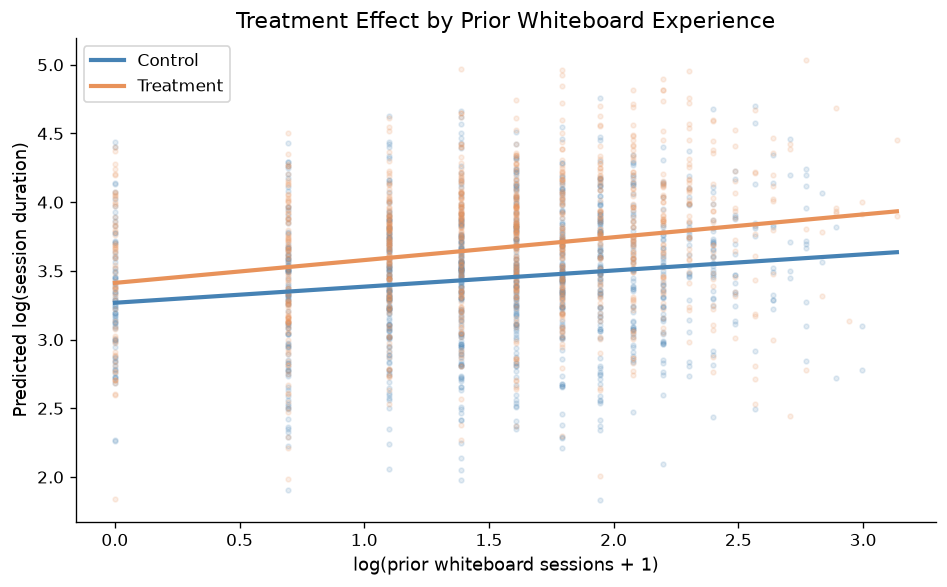

Interaction term coefficient: 0.048733488501939454
Interaction term p-value: 0.09641008449548989


In [165]:
# YOUR CODE HERE
# Visualize the interaction
# Example: plot mean log(outcome) for treatment vs control, split by the moderating variable
# Use a grouped bar chart or overlapping regression lines

ws_range = np.linspace(X_int['log_whiteboard_sessions'].min(),
                        X_int['log_whiteboard_sessions'].max(), 200)

row_means = X_int.mean().values

def pred_line(ab_val):
    df = pd.DataFrame(np.tile(row_means, (len(ws_range), 1)), columns=X_int.columns)
    df['ab_group'] = ab_val
    df['log_whiteboard_sessions'] = ws_range
    df['ab_x_log_whiteboard'] = ab_val * ws_range
    df.insert(0, 'const', 1.0)
    return model_int.predict(sm.add_constant(df))

pred_ctrl = pred_line(0)
pred_trt  = pred_line(1)

fig, ax = plt.subplots(figsize=(8, 5))
ctrl_mask = (df_ab['ab_group'] == 'control').values
trt_mask  = (df_ab['ab_group'] == 'treatment').values
ax.scatter(X_int.loc[ctrl_mask, 'log_whiteboard_sessions'], y[ctrl_mask],
           alpha=0.15, s=8, color='steelblue')
ax.scatter(X_int.loc[trt_mask,  'log_whiteboard_sessions'], y[trt_mask],
           alpha=0.15, s=8, color=ACCENT)
ax.plot(ws_range, pred_ctrl, color='steelblue', lw=2.5, label='Control')
ax.plot(ws_range, pred_trt,  color=ACCENT,      lw=2.5, label='Treatment')
ax.set_xlabel('log(prior whiteboard sessions + 1)')
ax.set_ylabel('Predicted log(session duration)')
ax.set_title('Treatment Effect by Prior Whiteboard Experience')
ax.legend()
plt.tight_layout()
plt.show()

print("Interaction term coefficient:", model_int.params['ab_x_log_whiteboard'])
print("Interaction term p-value:", model_int.pvalues['ab_x_log_whiteboard'])

**✏️ Your interpretation (A4):**

*Was your hypothesis supported? What does the interaction coefficient tell you about which users benefit most from the AI assistant? What does this imply for how Phigma should roll out the feature?*


The hypothesis was not supported. The interaction coefficient on `ab_group × log_prior_whiteboard_sessions` was β = 0.049. This tells us that the treatment effect grows very slightly as prior experience increases, but the result was not statistically significant (p = 0.096), so this pattern could be due to chance.


For Phigma, this means there is no strong basis for targeting the AI assistant rollout at a specific experience segment. A uniform rollout is reasonable, though the trend in the data (experienced users responding slightly more) would be worth revisiting with a larger sample if Phigma wants to make experience-based targeting decisions.



---

## Part B — Logistic Regression: Who Converts?

**Dataset:** `phigma_subscription.csv`  
**Research question:** Which behavioral and demographic factors predict whether a free-tier user subscribes within 30 days?

This dataset requires **feature engineering before modeling**. Several columns arrive as raw datetimes or aggregate counts that need transformation.


In [166]:
df_sub = pd.read_csv('phigma_subscription.csv')

print(f"Shape: {df_sub.shape}")
print(f"\nColumn types:\n{df_sub.dtypes}")
df_sub.head(3)


Shape: (3000, 15)

Column types:
user_id                           str
signup_date                       str
first_session_date                str
device_type                       str
country_tier                      str
referral_source                   str
num_sessions_30d                int64
total_time_min_30d              int64
projects_created_30d            int64
exports_30d                     int64
collaborators_invited_30d       int64
support_tickets_30d             int64
used_premium_feature_preview    int64
ai_assistant_sessions_30d       int64
subscribed                      int64
dtype: object


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
0,V94735,2024-05-23,2024-05-28,tablet,tier_1,organic,1,96,1,0,0,0,1,6,0
1,V15501,2024-03-05,2024-03-05,tablet,tier_2,social,15,267,8,1,5,0,0,0,0
2,V98542,2024-01-05,2024-01-19,desktop,tier_1,organic,16,263,0,0,3,3,1,4,1


In [167]:
df_sub.describe(include='all').round(2)


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
count,3000,3000,3000,3000,3000,3000,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
unique,2947,181,200,3,3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,V43688,2024-06-06,2024-06-27,desktop,tier_1,organic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3,33,29,1788,1332,1153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,9.25,216.17,2.43,2.01,1.86,0.68,0.28,3.64,0.21
std,NaN,NaN,NaN,NaN,NaN,NaN,5.09,139.20,2.30,2.05,2.10,1.07,0.45,2.90,0.41
min,NaN,NaN,NaN,NaN,NaN,NaN,1.00,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,NaN,NaN,NaN,NaN,NaN,NaN,6.00,115.75,1.00,0.00,0.00,0.00,0.00,2.00,0.00
50%,NaN,NaN,NaN,NaN,NaN,NaN,8.00,188.50,2.00,2.00,1.00,0.00,0.00,3.00,0.00
75%,NaN,NaN,NaN,NaN,NaN,NaN,12.00,285.00,4.00,3.00,3.00,1.00,1.00,5.00,0.00


### B1 — Feature Engineering

Derive the required features listed in the README before doing any modeling or EDA.


In [ ]:
# YOUR CODE HERE

# 1. Parse dates
df_sub['signup_date'] = pd.to_datetime(df_sub['signup_date'])
df_sub['first_session_date'] = pd.to_datetime(df_sub['first_session_date'])

# 2. days_to_first_session
df_sub['days_to_first_session'] = (df_sub['first_session_date'] - df_sub['signup_date']).dt.days

# 3. avg_session_duration_min — handle divide-by-zero explicitly
df_sub['avg_session_duration_min'] = np.where(
    df_sub['num_sessions_30d'] == 0,
    0,
    df_sub['total_time_min_30d'] / df_sub['num_sessions_30d']
)


# 4. is_weekend_signup (1 if Saturday=5 or Sunday=6)
df_sub['is_weekend_signup'] = df_sub['signup_date'].dt.weekday.isin([5, 6]).astype(int)

# 5. One-hot encode device_type (drop first level)
device_dummies2 = pd.get_dummies(df_sub['device_type'], prefix='device', drop_first=True)

# 6. One-hot encode referral_source (drop first level)
referral_dummies = pd.get_dummies(df_sub['referral_source'], prefix='ref', drop_first=True)

# 7. Encode country_tier — ordinal or one-hot (justify below)
# Option A (ordinal): df_sub['country_tier_enc'] = df_sub['country_tier'].map({'tier_1':1,'tier_2':2,'tier_3':3})
# Option B (one-hot): pd.get_dummies(...)

# 8. Assemble final feature matrix

drop_cols = ['user_id', 'signup_date', 'first_session_date',
             'device_type', 'referral_source', 'country_tier', 'subscribed']
X_sub = pd.concat([
    df_sub.drop(columns=drop_cols),
    device_dummies2,
    referral_dummies
], axis=1)
y_sub = df_sub['subscribed']

# Confirm
print(f"Any inf: {np.isinf(X_sub.values).any()}")
print(f"Any NaN: {X_sub.isnull().any().any()}")
print(f"Feature matrix shape: {X_sub.shape}")
X_sub.head(3)


KeyError: "['pages_visited'] not in index"

**✏️ Your interpretation (B1):**

*For each engineered feature, one sentence: why might it predict subscription? Also describe how you handled the divide-by-zero edge case for `avg_session_duration_min`.*


### B2 — EDA for Subscription


In [ ]:
# Subscription rate
rate = df_sub['subscribed'].mean()
n_pos = df_sub['subscribed'].sum()
n_total = len(df_sub)
print(f"Subscription rate: {rate:.1%}  ({n_pos} / {n_total})")
print(f"Class balance — 0: {n_total - n_pos}  |  1: {n_pos}")


Subscription rate: 20.8%  (625 / 3000)
Class balance — 0: 2375  |  1: 625


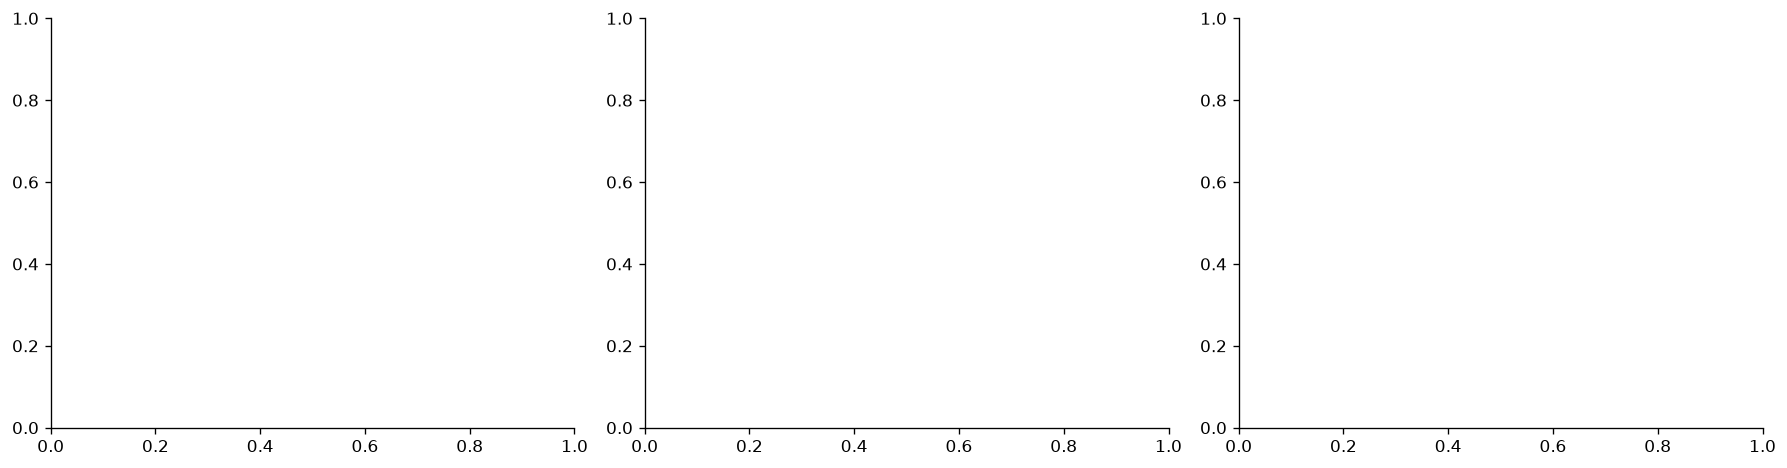

In [ ]:
# YOUR CODE HERE
# Visualize subscription rates across at least 3 features
# Suggestions:
#   - Bar chart: subscription rate by referral_source
#   - Bar chart: subscription rate by country_tier
#   - Boxplot: exports_30d distribution by subscribed (0 vs 1)
#   - Bar chart: subscription rate by used_premium_feature_preview
#   - Any other feature you find interesting

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — YOUR CODE
# axes[0]: ...

# Plot 2 — YOUR CODE
# axes[1]: ...

# Plot 3 — YOUR CODE
# axes[2]: ...

plt.tight_layout()
plt.show()


In [ ]:
# YOUR CODE HERE
# Correlation matrix of numeric features (exclude user_id and binary outcome)
# numeric_features = X_sub.select_dtypes(include='number').columns.tolist()
# corr = X_sub[numeric_features].corr()
# Plot as heatmap


**✏️ Your interpretation (B2):**

*Which two or three features appear most strongly associated with subscription in your EDA? Are any findings counterintuitive? Note any features that appear highly correlated with each other — does this concern you?*


### B3 — Logistic Regression with statsmodels (Inferential)

We fit on the **full dataset** here to maximize statistical power for inference.  
No train/test split — the goal is to interpret coefficients, not evaluate prediction.


In [ ]:
# YOUR CODE HERE
# X_const_sub = sm.add_constant(X_sub)
# model_logit = sm.Logit(y_sub, X_const_sub).fit()
# print(model_logit.summary())


In [ ]:
# YOUR CODE HERE
# Compute odds ratios for all significant predictors (p < 0.05)
# odds_ratios = np.exp(model_logit.params)
# conf_int    = np.exp(model_logit.conf_int())
# Combine into a readable table and display
# Filter to significant only: p < 0.05


In [ ]:
# YOUR CODE HERE
# Visualize odds ratios as a horizontal bar chart (forest plot style)
# Show confidence intervals if possible
# Order bars by magnitude


**✏️ Results paragraph (B3):**

*Interpret at least three odds ratios in plain English (e.g. "Users who previewed a premium feature were X times more likely to subscribe..."). Identify at least one predictor whose sign or magnitude surprised you and offer an explanation.*


### B4 — Logistic Regression with sklearn (Predictive)


In [ ]:
# YOUR CODE HERE
# Train/test split — use these exact parameters so Part C comparisons are valid
# X_train, X_test, y_train, y_test = train_test_split(
#     X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
# )
# print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
# print(f"Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}")


In [ ]:
# YOUR CODE HERE
# Fit sklearn LogisticRegression
# clf_lr = LogisticRegression(max_iter=1000, random_state=42)
# clf_lr.fit(X_train, y_train)
# y_pred_lr = clf_lr.predict(X_test)
# y_prob_lr = clf_lr.predict_proba(X_test)[:, 1]


In [ ]:
# YOUR CODE HERE
# Confusion matrix heatmap
# cm_lr = confusion_matrix(y_test, y_pred_lr)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not subscribed', 'Subscribed'])
# fig, ax = plt.subplots(figsize=(5, 4))
# disp.plot(ax=ax, cmap='Blues', colorbar=False)
# plt.title('Logistic Regression — Confusion Matrix')
# plt.show()


In [ ]:
# YOUR CODE HERE
# Classification report
# print(classification_report(y_test, y_pred_lr, target_names=['Not subscribed', 'Subscribed']))
# print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")


In [ ]:
# YOUR CODE HERE
# ROC curve (save fpr_lr, tpr_lr for later comparison with Part C)
# fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
# auc_lr = roc_auc_score(y_test, y_prob_lr)

# fig, ax = plt.subplots(figsize=(6, 5))
# ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
# ax.plot([0,1],[0,1], 'k--', lw=0.8)
# ax.set_xlabel('False Positive Rate')
# ax.set_ylabel('True Positive Rate')
# ax.set_title('ROC Curve — Logistic Regression')
# ax.legend()
# plt.show()


**✏️ Your interpretation (B4):**

*Which metric did you decide is most important given the class imbalance, and why? Interpret the confusion matrix: how many false negatives does the model produce? From Phigma's business perspective, what is the cost of a false negative (a user who would have subscribed but the model missed)?*


---

## Part C — Your Model: Choose, Learn, Apply, Compare

**Dataset:** `phigma_subscription.csv`  
**Same train/test split as B4.** Do not re-split.


### C1 — Choose Your Model

Available options: Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, K-Nearest Neighbors, Naive Bayes, SVM, LDA, AdaBoost.


**✏️ Your chosen model:** `[Model name here]`

**Conceptual explanation (write this before any code):**

*3–5 sentences. How does this model learn from training data? What does it optimize? How is it structurally different from logistic regression? Why might it perform differently on this particular dataset given what you know about the features?*


### C2 — Fit and Evaluate


In [ ]:
# YOUR CODE HERE
# Import your chosen model, e.g.:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB
# from sklearn.svm import SVC
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
# from xgboost import XGBClassifier  # pip install xgboost
# from lightgbm import LGBMClassifier  # pip install lightgbm

# Fit with default hyperparameters
# clf_c = YourModel(random_state=42)   # add random_state if supported
# clf_c.fit(X_train, y_train)
# y_pred_c = clf_c.predict(X_test)
# y_prob_c = clf_c.predict_proba(X_test)[:, 1]  # omit if model has no predict_proba (e.g. SVM)


In [ ]:
# YOUR CODE HERE
# Confusion matrix


In [ ]:
# YOUR CODE HERE
# Classification report + ROC-AUC


In [ ]:
# YOUR CODE HERE
# ROC curve (save fpr_c, tpr_c, auc_c for comparison plot)


### C3 — Model Comparison


In [ ]:
# YOUR CODE HERE
# Summary comparison table
# metrics = {
#     'Model': ['Logistic Regression', 'YOUR MODEL NAME'],
#     'ROC-AUC': [...],
#     'F1 (class 1)': [...],
#     'Precision (class 1)': [...],
#     'Recall (class 1)': [...],
# }
# pd.DataFrame(metrics).set_index('Model').round(4)


In [ ]:
# YOUR CODE HERE
# Dual ROC curve plot
# fig, ax = plt.subplots(figsize=(7, 5))
# ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC={auc_lr:.3f})')
# ax.plot(fpr_c, tpr_c, color='steelblue', lw=2, label=f'YOUR MODEL (AUC={auc_c:.3f})')
# ax.plot([0,1],[0,1], 'k--', lw=0.8, label='Random baseline')
# ax.set_xlabel('False Positive Rate')
# ax.set_ylabel('True Positive Rate')
# ax.set_title('ROC Curve Comparison')
# ax.legend()
# plt.show()


**✏️ Comparison paragraph (C3):**

*Which model performs better, and by how much? Explain *why* the performance difference occurred — based on what you know about how each model works and the structure of this dataset (non-linearities, class imbalance, number of features). If your model performed worse than logistic regression, that is a valid finding — explain why.*


### C4 — Bonus: Hyperparameter Tuning (+5 points)

*Complete this section only if you want to attempt the bonus.*


In [ ]:
# YOUR CODE HERE (BONUS)
# from sklearn.model_selection import GridSearchCV  # or RandomizedSearchCV

# Define a parameter grid relevant to your chosen model
# param_grid = { ... }

# Run cross-validated search on the TRAINING SET ONLY
# search = GridSearchCV(YourModel(), param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
# search.fit(X_train, y_train)

# print(f"Best parameters: {search.best_params_}")
# print(f"Best CV AUC:     {search.best_score_:.4f}")

# Evaluate tuned model on test set
# y_pred_tuned = search.best_estimator_.predict(X_test)
# y_prob_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
# print(f"Tuned test AUC:  {roc_auc_score(y_test, y_prob_tuned):.4f}")
# print(f"Default test AUC:{auc_c:.4f}")
# print("Did tuning meaningfully improve results? [Your one sentence here]")


---

## Submission Checklist

Before submitting, confirm:

- [ ] All `# YOUR CODE HERE` cells are completed and run without errors
- [ ] All `**✏️ Your interpretation**` cells contain your own written analysis
- [ ] The notebook runs top-to-bottom without errors (`Kernel > Restart & Run All`)
- [ ] File is named `iat461_a2_[YourName]_[SFUid].ipynb`
- [ ] PDF export is named `iat461_a2_[YourName]_[SFUid].pdf`
- [ ] All AI-assisted code blocks include `#BEGIN` / `#END` disclosure comments
